# Corr of PMID_35561311 and ASO data  
gene exp matrix & GSEA NES

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from adjustText import adjust_text
import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [6]:
def compare_correlation(df1_path, df2_path, col_name, match_by, plot_title, df1_name, df2_name, filter_column = None, filter_threshold = None, annotate = False, save = False):

	df1 = pd.read_csv(df1_path, sep="\t")
	df2 = pd.read_csv(df2_path, sep="\t")

	merged = pd.merge(df1, df2, on=match_by, suffixes=('_df1', '_df2'))

	merged = merged.dropna(subset=[f"{col_name}_df1", f"{col_name}_df2"])
	if filter_column is not None:
		merged = merged[(merged[f"{filter_column}_df1"] < filter_threshold) & (merged[f"{filter_column}_df2"] < filter_threshold)]
	print(merged.head(15))

	x = merged[f"{col_name}_df1"]
	y = merged[f"{col_name}_df2"]
	labels = merged[match_by]

	pearson_r, _ = pearsonr(x, y)
	spearman_r, _ = spearmanr(x, y)
	n = len(merged)

	if annotate:
		plt.figure(figsize=(6, 4))
		plt.scatter(x, y, c='#AA66FF', alpha=0.8, s=15)
	else:
		plt.figure(figsize=(4, 4))
		plt.scatter(x, y, c='#AA66FF', alpha=0.6, s=5)
	plt.xlabel(df1_name, fontsize=12)
	plt.ylabel(df2_name, fontsize=12)

	text_str = f"Pearson r = {pearson_r:.3f}\nSpearman r = {spearman_r:.3f}"
	plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes,
				fontsize=12, verticalalignment='top')
	
	ax = plt.gca()
	if annotate:
		xmax = x.max()
		xmin = x.min()
		x_range = xmax - xmin
		x_offset = x_range * 0.05
		x_text = xmax + x_range * 0.15

		data_for_labels = sorted(zip(x, y, labels), key=lambda v: v[1])
		n_labels = len(data_for_labels)

		y_label_positions = np.linspace(min(y), max(y), n_labels)

		for (xi, yi, label), y_text in zip(data_for_labels, y_label_positions):
			ax.plot([xi, x_text], [yi, y_text],
					lw=0.5, color='gray', alpha=0.7)

			ax.text(
				x_text, y_text, label.split("_", 1)[1],
				va='center', ha='left',
				fontsize=11, color='black'
			)

		ax.set_xlim(xmin - x_offset, x_text + x_offset)

	plt.title(f"{plot_title}\n(N={n})", fontsize=13)
	plt.tick_params(axis='both', labelsize=12)
	plt.grid(False)
	ax = plt.gca()
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	plt.tight_layout()
	if save:
		plt.savefig("/media/scratch/fy2306/projects/base_editing/plots/ASO/GSEA.wSTING.pdf", 
					bbox_inches="tight",
					dpi=300,              
					transparent=True,
					format='pdf')
	plt.show()

            gene_id  baseMean_df1  log2FoldChange_df1  lfcSE_df1  stat_df1  \
0   ENSG00000000003   1240.531674            0.149527   0.151496  0.987005   
1   ENSG00000000419    977.382282           -0.274019   0.146109 -1.875439   
2   ENSG00000000457    264.997353            0.524427   0.204569  2.563569   
3   ENSG00000000460    864.898233           -0.163468   0.140939 -1.159849   
4   ENSG00000000971     22.905392            0.118250   0.468332  0.252491   
5   ENSG00000001036   3691.503860            0.168544   0.127609  1.320778   
6   ENSG00000001084   1428.074796            0.214028   0.212454  1.007407   
7   ENSG00000001167   2308.028056           -0.490403   0.215616 -2.274429   
8   ENSG00000001460    332.865390           -0.637475   0.190469 -3.346870   
9   ENSG00000001461   1698.717890           -0.853580   0.221867 -3.847260   
10  ENSG00000001497   1694.077310           -0.178854   0.162764 -1.098858   
11  ENSG00000001617     88.563667           -0.102149   0.313217

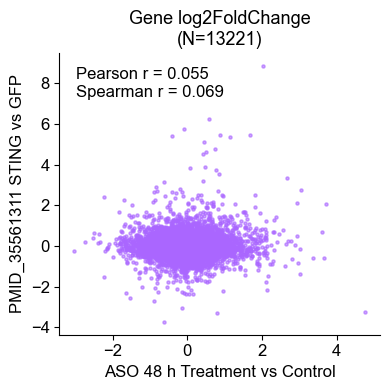

             gene_id  baseMean_df1  log2FoldChange_df1  lfcSE_df1  stat_df1  \
39   ENSG00000004478   5533.826021            0.469311   0.174543  2.688800   
79   ENSG00000005884  30467.970060           -0.708401   0.118315 -5.987427   
98   ENSG00000006576   2090.074067            0.667676   0.136846  4.879026   
173  ENSG00000010278   3694.724811            0.662816   0.244854  2.706981   
185  ENSG00000010803    716.617823           -0.671522   0.243712 -2.755389   
221  ENSG00000012211    369.643221            0.824439   0.249074  3.310015   
231  ENSG00000013306   3346.047432           -0.443295   0.162085 -2.734952   
295  ENSG00000023287   1946.906330            0.817309   0.167868  4.868762   
309  ENSG00000024526   2742.756058            0.369339   0.130809  2.823512   
340  ENSG00000029153   1318.916271           -1.333984   0.230824 -5.779230   
492  ENSG00000050165    101.749187            1.237718   0.449253  2.755060   
498  ENSG00000050730     39.491809           -1.5693

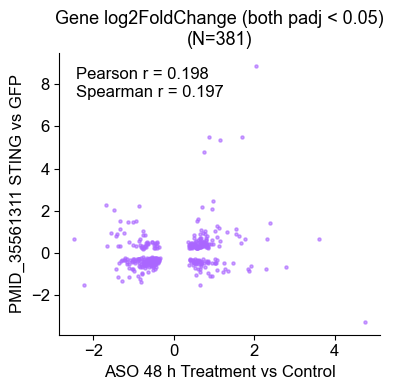

                                    ID                     Description_df1  \
0     HALLMARK_TNFA_SIGNALING_VIA_NFKB    HALLMARK_TNFA_SIGNALING_VIA_NFKB   
1   HALLMARK_INTERFERON_GAMMA_RESPONSE  HALLMARK_INTERFERON_GAMMA_RESPONSE   
2              HALLMARK_UV_RESPONSE_UP             HALLMARK_UV_RESPONSE_UP   
3     HALLMARK_CHOLESTEROL_HOMEOSTASIS    HALLMARK_CHOLESTEROL_HOMEOSTASIS   
4   HALLMARK_INTERFERON_ALPHA_RESPONSE  HALLMARK_INTERFERON_ALPHA_RESPONSE   
5                   HALLMARK_APOPTOSIS                  HALLMARK_APOPTOSIS   
6                 HALLMARK_E2F_TARGETS                HALLMARK_E2F_TARGETS   
7       HALLMARK_INFLAMMATORY_RESPONSE      HALLMARK_INFLAMMATORY_RESPONSE   
8   HALLMARK_UNFOLDED_PROTEIN_RESPONSE  HALLMARK_UNFOLDED_PROTEIN_RESPONSE   
9     HALLMARK_IL6_JAK_STAT3_SIGNALING    HALLMARK_IL6_JAK_STAT3_SIGNALING   
10           HALLMARK_MTORC1_SIGNALING           HALLMARK_MTORC1_SIGNALING   
11                 HALLMARK_COMPLEMENT                 HALLMARK_

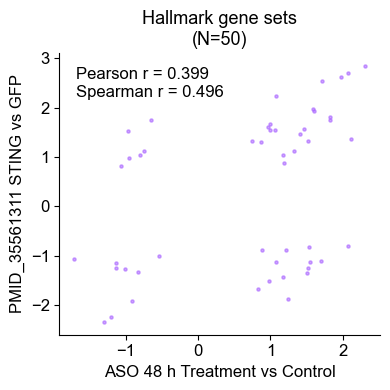

                                    ID                     Description_df1  \
0     HALLMARK_TNFA_SIGNALING_VIA_NFKB    HALLMARK_TNFA_SIGNALING_VIA_NFKB   
1   HALLMARK_INTERFERON_GAMMA_RESPONSE  HALLMARK_INTERFERON_GAMMA_RESPONSE   
4   HALLMARK_INTERFERON_ALPHA_RESPONSE  HALLMARK_INTERFERON_ALPHA_RESPONSE   
5                   HALLMARK_APOPTOSIS                  HALLMARK_APOPTOSIS   
7       HALLMARK_INFLAMMATORY_RESPONSE      HALLMARK_INFLAMMATORY_RESPONSE   
9     HALLMARK_IL6_JAK_STAT3_SIGNALING    HALLMARK_IL6_JAK_STAT3_SIGNALING   
11                 HALLMARK_COMPLEMENT                 HALLMARK_COMPLEMENT   
13        HALLMARK_ALLOGRAFT_REJECTION        HALLMARK_ALLOGRAFT_REJECTION   
15        HALLMARK_IL2_STAT5_SIGNALING        HALLMARK_IL2_STAT5_SIGNALING   

    setSize_df1  enrichmentScore_df1   NES_df1    pvalue_df1  p.adjust_df1  \
0           183             0.491756  2.315459  1.000000e-10  5.000000e-09   
1           173             0.441069  2.070766  1.575295e-08  3

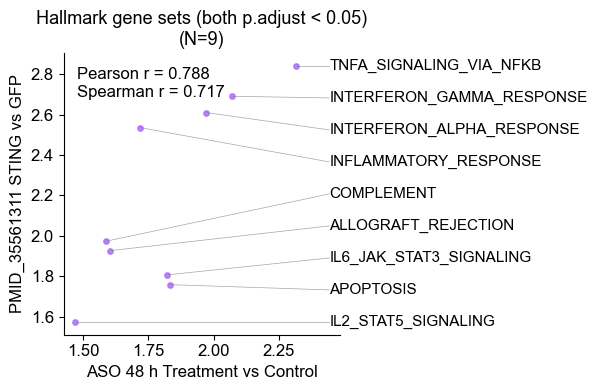

In [7]:
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/de_deseq2.48h.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/de_deseq2.tsv", 
	col_name = "log2FoldChange", 
	match_by = "gene_id", 
	plot_title = "Gene log2FoldChange", 
	df1_name = "ASO 48 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP")
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/de_deseq2.48h.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/de_deseq2.tsv", 
	col_name = "log2FoldChange", 
	match_by = "gene_id", 
	plot_title = "Gene log2FoldChange (both padj < 0.05)", 
	df1_name = "ASO 48 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP",
	filter_column = "padj",
	filter_threshold = 0.05)
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/enrichment_48h/gsea_msig_H_std.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/gsea_msig_H_std.tsv", 
	col_name = "NES", 
	match_by = "ID", 
	plot_title = "Hallmark gene sets", 
	df1_name = "ASO 48 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP")
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/enrichment_48h/gsea_msig_H_std.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/gsea_msig_H_std.tsv", 
	col_name = "NES", 
	match_by = "ID", 
	plot_title = "Hallmark gene sets (both p.adjust < 0.05)", 
	df1_name = "ASO 48 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP",
	filter_column = "p.adjust",
	filter_threshold = 0.05,
	annotate = True)

            gene_id  baseMean_df1  log2FoldChange_df1  lfcSE_df1  stat_df1  \
0   ENSG00000000003   1273.799390            0.092804   0.137693  0.673994   
1   ENSG00000000419    933.362468           -0.012528   0.119735 -0.104632   
2   ENSG00000000457    248.540909            0.291461   0.175455  1.661172   
3   ENSG00000000460   1053.566154           -0.100779   0.120684 -0.835061   
4   ENSG00000000971     17.268223           -0.083134   0.533947 -0.155697   
5   ENSG00000001036   3840.565850            0.214676   0.114939  1.867741   
6   ENSG00000001084    969.063147            0.037629   0.154811  0.243061   
7   ENSG00000001167   2624.422035           -0.270792   0.141903 -1.908286   
8   ENSG00000001460    374.256228           -0.312660   0.152914 -2.044676   
9   ENSG00000001461   1974.461759           -0.637254   0.147971 -4.306597   
10  ENSG00000001497   1796.411387           -0.181516   0.109234 -1.661717   
11  ENSG00000001617    102.592945           -0.167004   0.271511

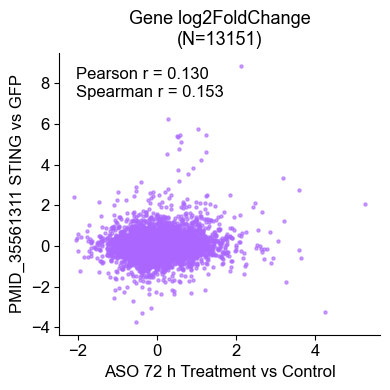

             gene_id  baseMean_df1  log2FoldChange_df1  lfcSE_df1  stat_df1  \
21   ENSG00000002834  29331.243425           -0.363215   0.116086 -3.128858   
44   ENSG00000004766    708.656016            0.360998   0.134369  2.686611   
78   ENSG00000005884  35096.236591           -0.607180   0.132501 -4.582471   
84   ENSG00000006062   3309.195378            1.207585   0.228363  5.288005   
97   ENSG00000006576   1997.119830            0.736670   0.185047  3.980981   
146  ENSG00000008441   3199.130232           -0.412552   0.128749 -3.204309   
183  ENSG00000010803    692.728925           -0.589534   0.145418 -4.054075   
215  ENSG00000012048   1551.258511            0.434435   0.144457  3.007361   
248  ENSG00000014216   6484.185374           -0.362303   0.127093 -2.850703   
259  ENSG00000015676   2929.541079           -0.452892   0.127912 -3.540664   
277  ENSG00000020426    850.954699            0.391470   0.134904  2.901837   
292  ENSG00000023191   5603.528877           -0.2839

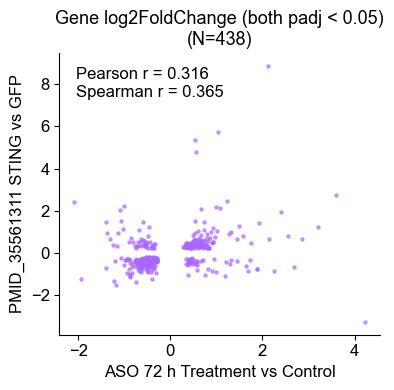

                                    ID                     Description_df1  \
0     HALLMARK_TNFA_SIGNALING_VIA_NFKB    HALLMARK_TNFA_SIGNALING_VIA_NFKB   
1              HALLMARK_MYC_TARGETS_V1             HALLMARK_MYC_TARGETS_V1   
2       HALLMARK_FATTY_ACID_METABOLISM      HALLMARK_FATTY_ACID_METABOLISM   
3                 HALLMARK_E2F_TARGETS                HALLMARK_E2F_TARGETS   
4   HALLMARK_INTERFERON_GAMMA_RESPONSE  HALLMARK_INTERFERON_GAMMA_RESPONSE   
5       HALLMARK_INFLAMMATORY_RESPONSE      HALLMARK_INFLAMMATORY_RESPONSE   
6              HALLMARK_UV_RESPONSE_UP             HALLMARK_UV_RESPONSE_UP   
7                  HALLMARK_GLYCOLYSIS                 HALLMARK_GLYCOLYSIS   
8   HALLMARK_INTERFERON_ALPHA_RESPONSE  HALLMARK_INTERFERON_ALPHA_RESPONSE   
9       HALLMARK_XENOBIOTIC_METABOLISM      HALLMARK_XENOBIOTIC_METABOLISM   
10             HALLMARK_G2M_CHECKPOINT             HALLMARK_G2M_CHECKPOINT   
11  HALLMARK_OXIDATIVE_PHOSPHORYLATION  HALLMARK_OXIDATIVE_PHOSP

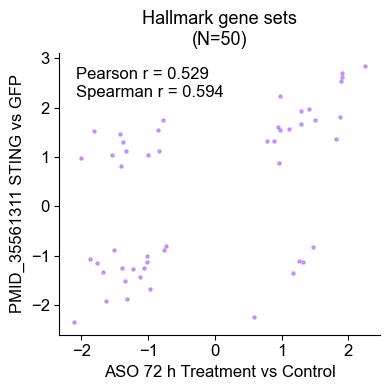

                                    ID                     Description_df1  \
0     HALLMARK_TNFA_SIGNALING_VIA_NFKB    HALLMARK_TNFA_SIGNALING_VIA_NFKB   
1              HALLMARK_MYC_TARGETS_V1             HALLMARK_MYC_TARGETS_V1   
4   HALLMARK_INTERFERON_GAMMA_RESPONSE  HALLMARK_INTERFERON_GAMMA_RESPONSE   
5       HALLMARK_INFLAMMATORY_RESPONSE      HALLMARK_INFLAMMATORY_RESPONSE   
8   HALLMARK_INTERFERON_ALPHA_RESPONSE  HALLMARK_INTERFERON_ALPHA_RESPONSE   
9       HALLMARK_XENOBIOTIC_METABOLISM      HALLMARK_XENOBIOTIC_METABOLISM   
11  HALLMARK_OXIDATIVE_PHOSPHORYLATION  HALLMARK_OXIDATIVE_PHOSPHORYLATION   
12    HALLMARK_IL6_JAK_STAT3_SIGNALING    HALLMARK_IL6_JAK_STAT3_SIGNALING   
13                  HALLMARK_APOPTOSIS                  HALLMARK_APOPTOSIS   
15                    HALLMARK_HYPOXIA                    HALLMARK_HYPOXIA   
17                 HALLMARK_COMPLEMENT                 HALLMARK_COMPLEMENT   
18               HALLMARK_ADIPOGENESIS               HALLMARK_AD

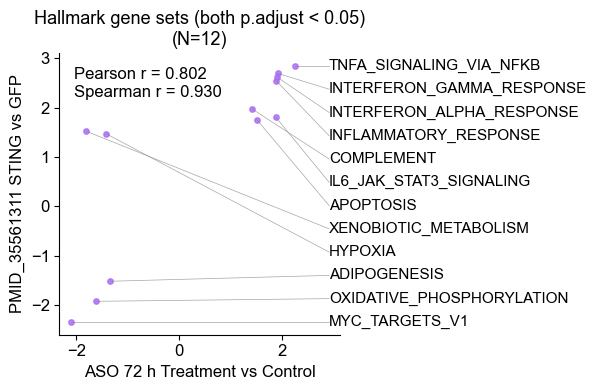

In [8]:
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/de_deseq2.72h.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/de_deseq2.tsv", 
	col_name = "log2FoldChange", 
	match_by = "gene_id", 
	plot_title = "Gene log2FoldChange", 
	df1_name = "ASO 72 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP")
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/de_deseq2.72h.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/de_deseq2.tsv", 
	col_name = "log2FoldChange", 
	match_by = "gene_id", 
	plot_title = "Gene log2FoldChange (both padj < 0.05)", 
	df1_name = "ASO 72 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP",
	filter_column = "padj",
	filter_threshold = 0.05)
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/enrichment_72h/gsea_msig_H_std.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/gsea_msig_H_std.tsv", 
	col_name = "NES", 
	match_by = "ID", 
	plot_title = "Hallmark gene sets", 
	df1_name = "ASO 72 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP")
compare_correlation(
	df1_path = "/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/enrichment_72h/gsea_msig_H_std.tsv", 
	df2_path = "/media/scratch/fy2306/projects/base_editing/results/PMID_35561311/gsea_msig_H_std.tsv", 
	col_name = "NES", 
	match_by = "ID", 
	plot_title = "Hallmark gene sets (both p.adjust < 0.05)", 
	df1_name = "ASO 72 h Treatment vs Control", 
	df2_name = "PMID_35561311 STING vs GFP",
	filter_column = "p.adjust",
	filter_threshold = 0.05,
	annotate = True,
	save = True)